In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from pandas.plotting import parallel_coordinates
import networkx as nx

# 1. LOAD DATA
info_raw = pd.read_csv('../data/merged/typhoon-info-infra-project.csv')
impact_raw = pd.read_csv('../data/merged/cleaned_typhoon_impacts.csv')

# 2. AGGREGATE INFO DATA 
# We group by Region and Year to capture the context of the disasters.
info_agg = info_raw.groupby(['Region', 'Year'], as_index=False).agg({
    'Max 24-hour Rainfall (mm)': 'max',
    'Peak Gust (10 mins sustained) (m/s)': 'max',
    'Cumulative_Budget_To_Date': 'sum',
    'Variance_Ratio_To_Date': 'mean'
})

# 3. MERGE
# This results in a dataset where each row is a regional disaster profile.
df = impact_raw.merge(info_agg, on=['Region', 'Year'], how='inner')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Cyclone Name                             283 non-null    object 
 1   Region                                   283 non-null    object 
 2   Year                                     283 non-null    int64  
 3   Category                                 283 non-null    object 
 4   Deaths                                   283 non-null    int64  
 5   Injuries                                 283 non-null    int64  
 6   Affected                                 283 non-null    int64  
 7   Houses destroyed                         283 non-null    int64  
 8   Houses damaged                           283 non-null    int64  
 9   Total Houses                             283 non-null    int64  
 10  Damage to Infrastructure (PhP)           283 non-n

In [4]:
df.head(15)

,Cyclone Name,Region,Year,Category,Deaths,Injuries,Affected,Houses destroyed,Houses damaged,Total Houses,Damage to Infrastructure (PhP),Damage to Agriculture + Fisheries (PhP),Max 24-hour Rainfall (mm),Peak Gust (10 mins sustained) (m/s),Cumulative_Budget_To_Date,Variance_Ratio_To_Date
0,Falcon,Region I,2019,Tropical Storm,0,0,5,0,1,1,9.140000e+08,0.000000e+00,471.8,21.666667,0.0,0.0
1,Falcon,Region II,2019,Tropical Storm,0,0,502,0,0,0,1.188795e+08,3.655604e+07,366.6,30.000000,0.0,0.0
2,Marilyn,Region II,2019,Tropical Depression,0,0,0,0,0,0,0.000000e+00,0.000000e+00,366.6,30.000000,0.0,0.0
3,Marilyn,Region III,2019,Tropical Depression,0,0,0,0,0,0,0.000000e+00,0.000000e+00,231.5,0.000000,0.0,0.0
4,Marilyn,Region VI,2019,Tropical Depression,0,0,0,0,0,0,0.000000e+00,0.000000e+00,155.0,43.000000,0.0,0.0
5,Tino,Region I,2019,Typhoon,0,0,521,0,0,0,0.000000e+00,0.000000e+00,471.8,21.666667,0.0,0.0
6,Tino,Region II,2019,Typhoon,0,0,20213,0,0,0,0.000000e+00,3.568939e+07,366.6,30.000000,0.0,0.0
7,Tino,Region V,2019,Typhoon,0,0,3290,10,9,19,0.000000e+00,0.000000e+00,298.8,40.000000,0.0,0.0
8,Tisoy,Region III,2019,Super Typhoon,0,0,21993,1,120,121,0.000000e+00,0.000000e+00,231.5,0.000000,0.0,0.0
9,Tisoy,Region IV-A,2019,Super Typhoon,3,0,116214,9108,1202,10310,0.000000e+00,6.683203e+08,111.4,13.500000,0.0,0.0


In [5]:
# ── 4. DISCRETIZATION ────────────────────────────────────────────
def discretize_data(data):
    df_bins = pd.DataFrame()
    df_bins['Rain_High'] = data['Max 24-hour Rainfall (mm)'] > data['Max 24-hour Rainfall (mm)'].median()
    df_bins['Budget_Low'] = data['Cumulative_Budget_To_Date'] < data['Cumulative_Budget_To_Date'].median()
    df_bins['Inefficient_Spending'] = data['Variance_Ratio_To_Date'] > data['Variance_Ratio_To_Date'].median()
    df_bins['Outcome_High_Mortality']= data['Deaths'] > data['Deaths'].median()
    df_bins['Outcome_High_Damage'] = data['Damage to Infrastructure (PhP)'] > data['Damage to Infrastructure (PhP)'].median()
    return df_bins

df_mining = discretize_data(df)

# ── 5. FREQUENT ITEMSETS ─────────────────────────────────────────
# min_support=0.05 means a pattern must appear in ≥5% of typhoon events
frequent_itemsets = apriori(df_mining, min_support=0.05, use_colnames=True)

# ── 6. GENERATE ALL RULES ────────────────────────────────────────
# min_threshold=1.1 means rule must be 10% more likely than random chance
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

# ── 7. FILTER: keep only rules that predict a disaster outcome ───
target_rules = rules[
    rules['consequents'].apply(lambda x: any('Outcome' in item for item in x))
].sort_values('lift', ascending=False).copy()

# ── 8. TRIM TO TOP 15 FOR VISUALIZATION ─────────────────────────
# Rules below lift ~1.8 are weak patterns — not worth plotting
top_rules = target_rules.head(15).copy()

# Color label: what does this rule actually predict?
def get_outcome_label(consequents):
    items = list(consequents)
    has_mort = any('Mortality' in i for i in items)
    has_dmg = any('Damage' in i for i in items)
    if has_mort and has_dmg: return 'Both outcomes'
    if has_mort: return 'Mortality'
    if has_dmg: return 'Damage'
    return 'Other'

# Short readable label for bubble annotations
def short_label(row):
    ant = ', '.join(sorted(row['antecedents']))
    ant = (ant
        .replace('Outcome_High_Mortality', 'Mortality')
        .replace('Outcome_High_Damage', 'Damage')
        .replace('Inefficient_Spending', 'Ineff.')
        .replace('Budget_Low', 'Budget↓')
        .replace('Rain_High', 'Rain↑'))
    return ant[:42] + '…' if len(ant) > 42 else ant

top_rules['outcome_type'] = top_rules['consequents'].apply(get_outcome_label)
top_rules['label'] = top_rules.apply(short_label, axis=1)

# ── 9. PRINT SUMMARY ─────────────────────────────────────────────
print(f"Total transactions : {len(df_mining)}")
print(f"All rules found : {len(rules)}")
print(f"Outcome rules : {len(target_rules)}")
print(f"Top rules (plotted): {len(top_rules)}")
print(f"Lift range in top : {top_rules['lift'].min():.2f} – {top_rules['lift'].max():.2f}")
print()
print("Top 15 rules by lift:")
print(top_rules[['antecedents','consequents','support','confidence','lift']]
    .round(3).to_string(index=False))

# ── 10. EXPORT ───────────────────────────────────────────────────
# Full outcome rules → for your report appendix
target_rules.to_csv('typhoon_association_rules_full.csv', index=False)
# Top 15 only → the ones you actually visualize
top_rules.to_csv('typhoon_association_rules_top15.csv', index=False)
print("Exported: typhoon_association_rules_full.csv + _top15.csv")

Total transactions : 283
All rules found : 44
Outcome rules : 32
Top rules (plotted): 15
Lift range in top : 1.64 – 2.52

Top 15 rules by lift:
                                              antecedents                                                         consequents  support  confidence  lift
                      (Rain_High, Outcome_High_Mortality)                         (Inefficient_Spending, Outcome_High_Damage)    0.053       0.517 2.524
              (Inefficient_Spending, Outcome_High_Damage)                                 (Rain_High, Outcome_High_Mortality)    0.053       0.259 2.524
                         (Rain_High, Outcome_High_Damage)                      (Inefficient_Spending, Outcome_High_Mortality)    0.053       0.238 2.246
           (Inefficient_Spending, Outcome_High_Mortality)                                    (Rain_High, Outcome_High_Damage)    0.053       0.500 2.246
                                    (Outcome_High_Damage)           (Rain_High, Inefficient

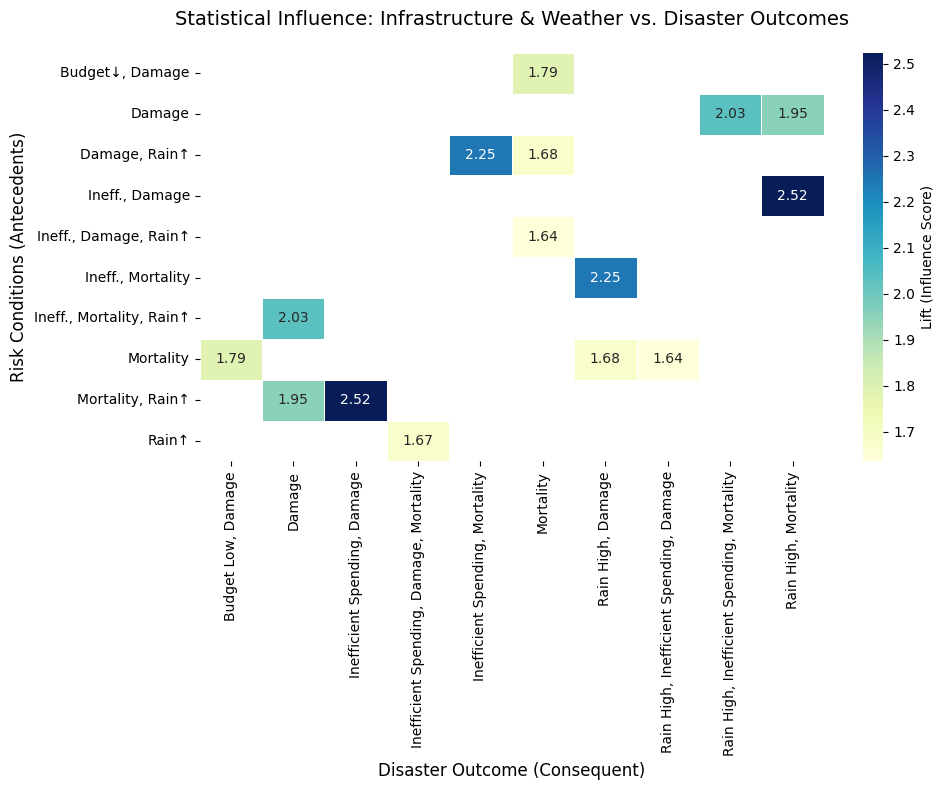

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_refined_heatmap(rules_df):
    if rules_df.empty:
        print("No rules to plot!")
        return

    # 1. Prepare data for the pivot
    # We use the 'label' column you created for the Y-axis (Antecedents)
    # And clean up the Consequent names for the X-axis
    plot_data = rules_df.copy()
    plot_data['consequent_label'] = plot_data['consequents'].apply(
        lambda x: ', '.join(list(x)).replace('Outcome_High_', '').replace('_', ' ')
    )
    
    # 2. Pivot the data
    # index = Conditions, columns = Outcomes, values = Lift
    pivot = plot_data.pivot(index='label', columns='consequent_label', values='lift')

    # 3. Create the visualization
    plt.figure(figsize=(10, 8))
    
    # We use 'annot=True' to show the Lift values (the 2.0s and 3.22s)
    sns.heatmap(pivot, 
                annot=True, 
                fmt=".2f", 
                cmap="YlGnBu", 
                cbar_kws={'label': 'Lift (Influence Score)'},
                linewidths=.5)

    plt.title("Statistical Influence: Infrastructure & Weather vs. Disaster Outcomes", fontsize=14, pad=20)
    plt.xlabel("Disaster Outcome (Consequent)", fontsize=12)
    plt.ylabel("Risk Conditions (Antecedents)", fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Run the visualization using your top 15 rules
plot_refined_heatmap(top_rules)

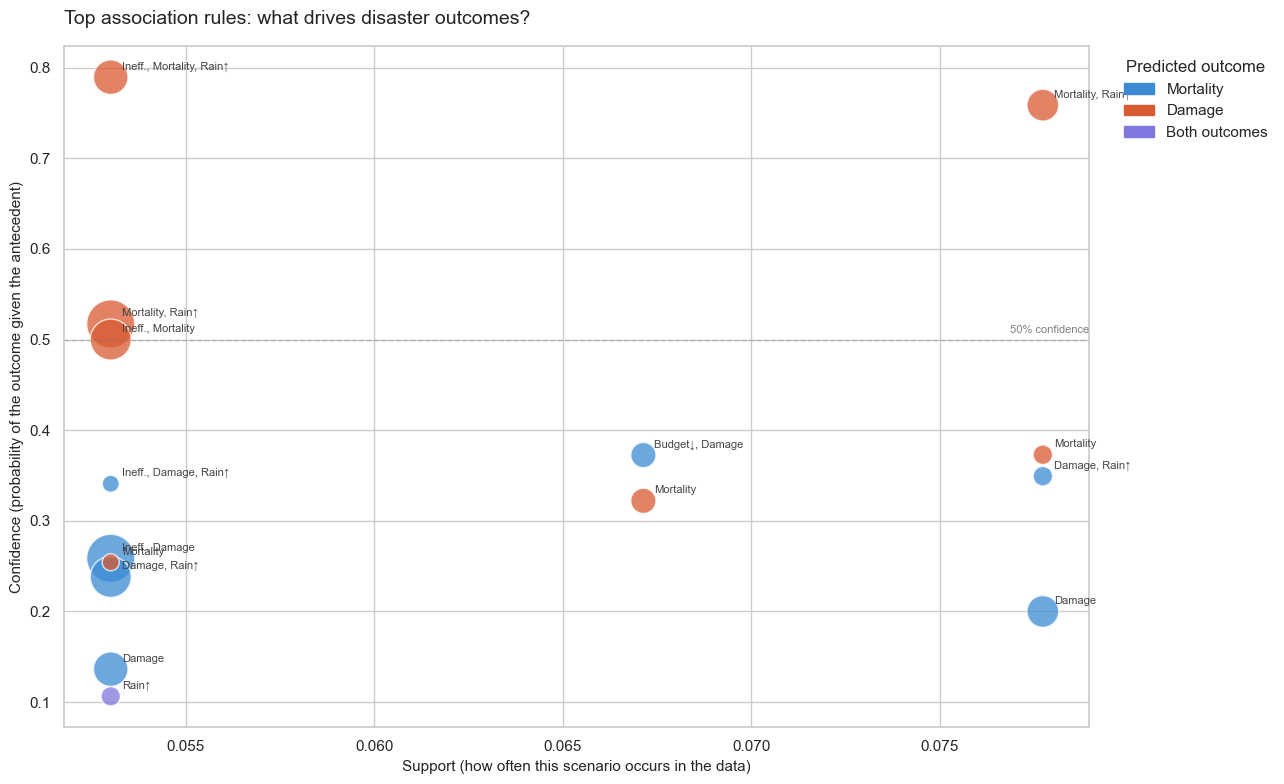

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 8))

# Color palette — meaningful, not decorative
palette = {
    'Mortality': '#3B8BD4', # blue
    'Damage': '#D85A30', # coral
    'Both outcomes': '#7F77DD', # purple
    'Other': '#888780', # gray
}

scatter = sns.scatterplot(
    data=top_rules,
    x='support',
    y='confidence',
    size='lift',
    hue='outcome_type', # ← now encodes WHAT is predicted
    sizes=(150, 1200),
    alpha=0.75,
    palette=palette,
    ax=ax
)

# Annotate each bubble with its short label
for _, row in top_rules.iterrows():
    ax.annotate(
        row['label'],
        xy=(row['support'], row['confidence']),
        xytext=(8, 4), textcoords='offset points',
        fontsize=8, color='#444',
        ha='left', va='bottom'
    )

# Reference lines
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.text(ax.get_xlim()[1], 0.505, '50% confidence', fontsize=8,
    color='gray', ha='right', va='bottom')

# Titles and labels
ax.set_title('Top association rules: what drives disaster outcomes?',
    fontsize=14, pad=16, loc='left')
ax.set_xlabel('Support (how often this scenario occurs in the data)', fontsize=11)
ax.set_ylabel('Confidence (probability of the outcome given the antecedent)', fontsize=11)

# Clean up legend — separate size from color
handles, labels = ax.get_legend_handles_labels()
color_handles = [mpatches.Patch(color=v, label=k) for k, v in palette.items()
                  if k in top_rules['outcome_type'].values]
ax.legend(handles=color_handles, title='Predicted outcome',
    bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('top_rules_chart.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# Cell 1 — how many rules do you have total?
print(f"Total rules (all consequents): {len(rules)}")
print(f"Target rules (outcome only): {len(target_rules)}")

Total rules (all consequents): 44
Target rules (outcome only): 32


In [9]:
print(target_rules[['antecedents','consequents','support','confidence','lift']]
    .sort_values('lift', ascending=False)
    .head(15)
    .to_string())

                                                  antecedents                                                          consequents   support  confidence      lift
36                        (Rain_High, Outcome_High_Mortality)                          (Inefficient_Spending, Outcome_High_Damage)  0.053004    0.517241  2.523781
37                (Inefficient_Spending, Outcome_High_Damage)                                  (Rain_High, Outcome_High_Mortality)  0.053004    0.258621  2.523781
35                           (Rain_High, Outcome_High_Damage)                       (Inefficient_Spending, Outcome_High_Mortality)  0.053004    0.238095  2.246032
38             (Inefficient_Spending, Outcome_High_Mortality)                                     (Rain_High, Outcome_High_Damage)  0.053004    0.500000  2.246032
42                                      (Outcome_High_Damage)            (Rain_High, Inefficient_Spending, Outcome_High_Mortality)  0.053004    0.136364  2.031100
31  (Rain_High, Ineffi

In [10]:
print(target_rules['lift'].describe().round(2))

count    32.00
mean      1.68
std       0.36
min       1.15
25%       1.47
50%       1.63
75%       1.83
max       2.52
Name: lift, dtype: float64


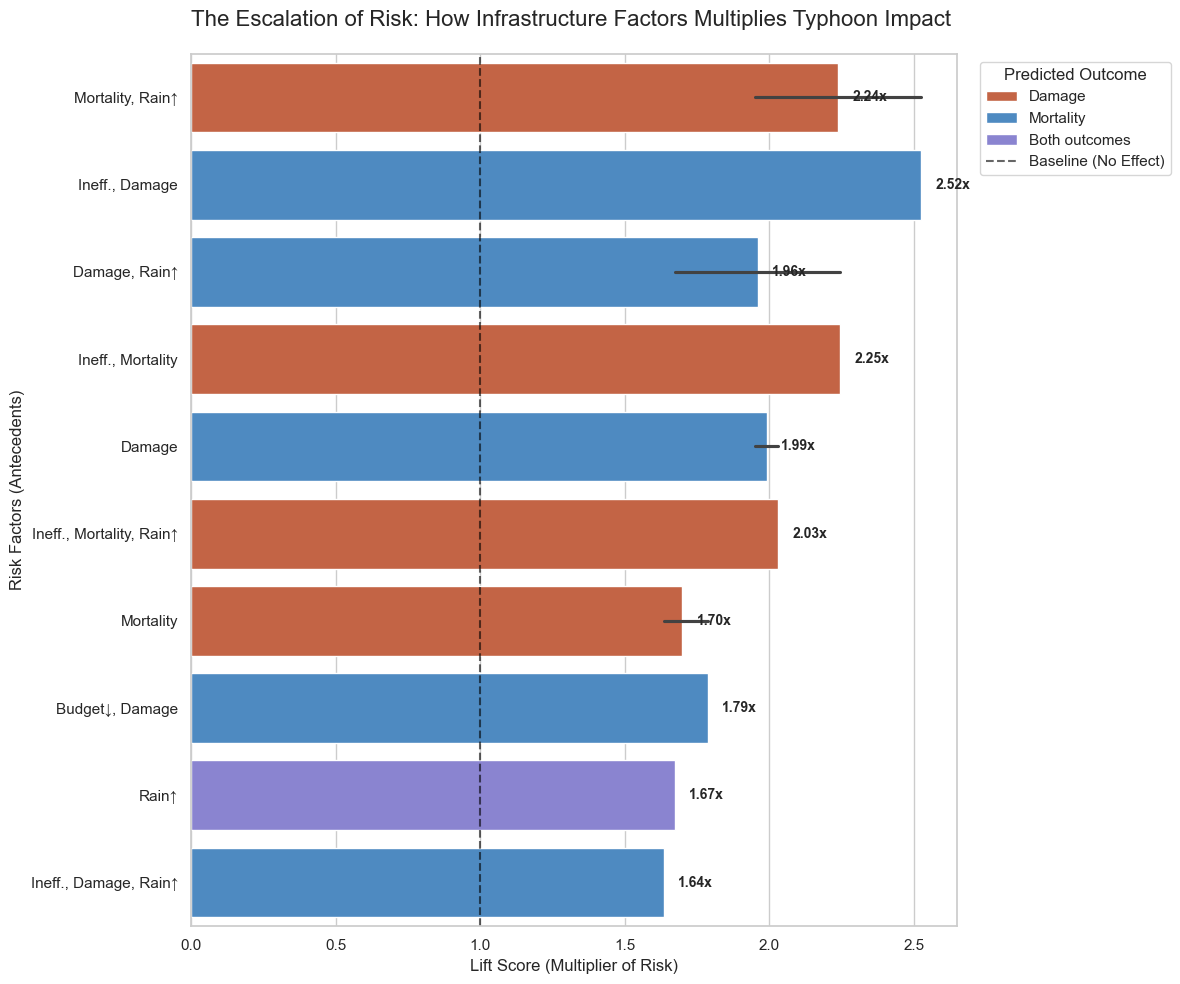

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# 2. Define the same professional color palette as your bubble plot
palette = {
    'Mortality': '#3B8BD4', 
    'Damage': '#D85A30', 
    'Both outcomes': '#7F77DD'
}

# 3. Create the Bar Chart
# We sort by lift so the most 'influential' rules are at the top
plot_df = top_rules.sort_values('lift', ascending=False)

barplot = sns.barplot(
    data=plot_df, 
    x='lift', 
    y='label', 
    hue='outcome_type',
    palette=palette,
    dodge=False # Keep bars aligned to their labels
)

# 4. Add a vertical 'Baseline' line at Lift = 1.0
# Anything past this line is 'extra' risk caused by the factors
plt.axvline(x=1.0, color='black', linestyle='--', alpha=0.6, label="Baseline (No Effect)")

# 5. Labeling for impact
plt.title("The Escalation of Risk: How Infrastructure Factors Multiplies Typhoon Impact", 
          fontsize=16, pad=20, loc='left')
plt.xlabel("Lift Score (Multiplier of Risk)", fontsize=12)
plt.ylabel("Risk Factors (Antecedents)", fontsize=12)

# Add value labels to the end of each bar
for p in barplot.patches:
    width = p.get_width()
    if width > 0: # Avoid labeling empty legend patches
        plt.text(width + 0.05, p.get_y() + p.get_height()/2, 
                 f'{width:.2f}x', va='center', fontsize=10, fontweight='bold')

plt.legend(title="Predicted Outcome", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()